In [ ]:
# ===== Cell 1: Import library, set seed, dan fungsi utilitas =====

# Import library numpy untuk komputasi numerik
import numpy as np
# Import library pandas untuk manipulasi data
import pandas as pd
# Import matplotlib untuk visualisasi plot
import matplotlib.pyplot as plt
# Import MinMaxScaler untuk normalisasi data
from sklearn.preprocessing import MinMaxScaler
# Import TimeSeriesSplit dan train_test_split untuk pembagian data
from sklearn.model_selection import TimeSeriesSplit, train_test_split
# Import metric untuk evaluasi model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Import os untuk operasi sistem
import os
# Import warnings untuk mengatur peringatan
import warnings
# Mengabaikan semua peringatan
warnings.filterwarnings('ignore')
# Set seed untuk reproduktibilitas hasil
np.random.seed(42)

# Fungsi utilitas untuk menghitung metrik dan menampilkan dengan rapi
def compute_metrics(y_true, y_pred, name=""):
    # Menghitung Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    # Menghitung Root Mean Squared Error
    rmse = np.sqrt(mse)
    # Menghitung Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    # Menghitung R-squared Score
    r2 = r2_score(y_true, y_pred)

    # Menampilkan hasil metrik
    print(f"--- Metrik {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    # Mengembalikan hasil metrik dalam bentuk dictionary
    return {'MAE':mae, 'MSE':mse, 'RMSE':rmse, 'R2':r2}

In [ ]:
# ===== Cell 2: Memuat data (dari /mnt/data) dan inspeksi =====

# Menentukan path file data
file_path = '/content/Data_SIPADU_Mei-Sep2025_FIKS.xlsx'

# Memeriksa apakah file exists di path yang ditentukan
if os.path.exists(file_path):
    # Jika file ada, load data dari file Excel
    df = pd.read_excel(file_path)
    # Menampilkan pesan berhasil load
    print("File berhasil dimuat:", file_path)
else:
    # Jika file tidak ditemukan, buat dataset dummy untuk demo
    print("File tidak ditemukan. Membuat dataset dummy untuk demonstrasi.")

    # Menentukan jumlah data (256 sampel)
    n = 256
    # Generate data suhu acak antara 20-35 derajat
    temp = np.random.uniform(20, 35, n)
    # Generate data kelembapan acak antara 50-95%
    hum = np.random.uniform(50, 95, n)
    # Generate pola pagi-malam bergantian (1=pagi, 0=malam)
    day_night = np.tile([1,0], n//2)
    # Generate volume air berdasarkan formula dengan noise
    vol = (0.4*temp) + (1.2*hum) + (8*day_night) + np.random.normal(0,5,n)
    # Generate tanggal dari Mei 2025 dengan interval 12 jam
    dates = pd.date_range(start='2025-05-01', periods=n, freq='12H')
    # Membuat DataFrame dari data yang telah digenerate
    df = pd.DataFrame({
        'Tanggal': dates,      # Kolom tanggal
        'Suhu': temp,          # Kolom suhu
        'Kelembapan': hum,     # Kolom kelembapan
        'Pagi': day_night,     # Kolom indikator pagi/malam
        'Air(ml)': np.clip(vol,0,None)  # Kolom volume air, dipastikan tidak negatif
    })

# Menampilkan daftar kolom yang ada
print("Kolom yang tersedia:", df.columns.tolist())
# Menampilkan 5 baris pertama data
display(df.head())
# Menampilkan bentuk/dimensi data (baris x kolom)
print("\nBentuk data:", df.shape)

File berhasil dimuat: /content/Data_SIPADU_Mei-Sep2025_FIKS.xlsx
Kolom yang tersedia: ['Tanggal', 'Jam', 'Pagi', 'Malam', 'Air(ml)', 'Suhu', 'Kelembaban']


,Tanggal,Jam,Pagi,Malam,Air(ml),Suhu,Kelembaban
0,23-May-25,8.0,1,0,30,30.5,90.8
1,23-May-25,20.0,0,1,32,30.0,86.3
2,24-May-25,8.0,1,0,44,30.4,90.6
3,24-May-25,20.0,0,1,57,29.8,88.0
4,25-May-25,8.0,1,0,48,30.5,82.0



Bentuk data: (256, 7)


In [ ]:
# ===== Cell 3: Membersihkan nama kolom dan memastikan kolom yang diperlukan =====

# Normalisasi nama kolom (menghapus spasi di awal/akhir)
df.columns = df.columns.str.strip()

# Mencari kolom output yang diharapkan (mengandung kata 'air' atau 'volume')
expected_outputs = [c for c in df.columns if 'air' in c.lower() or 'volume' in c.lower()]

# Mencari kolom input yang diharapkan (mengandung kata 'suhu' atau 'kelembaban')
expected_inputs = [c for c in df.columns if 'suhu' in c.lower() or 'kelem' in c.lower() or 'kelemb' in c.lower()]

# Menampilkan kolom kandidat yang terdeteksi
print("Kolom target kandidat yang terdeteksi:", expected_outputs)
print("Kolom input kandidat yang terdeteksi:", expected_inputs)

# Standarisasi nama kolom target
if 'Air(ml)' in df.columns:
    target_col = 'Air(ml)'
elif expected_outputs:
    target_col = expected_outputs[0]  # Ambil kolom pertama yang terdeteksi
else:
    raise ValueError("Kolom target (Air/Volume) tidak ditemukan dalam dataset.")

# Mencari nama kolom suhu
temp_col = next((c for c in df.columns if 'suhu' in c.lower()), None)

# Mencari nama kolom kelembaban
hum_col = next((c for c in df.columns if 'kelemb' in c.lower() or 'kelema' in c.lower()), None)

# Validasi apakah kolom suhu dan kelembaban ditemukan
if temp_col is None or hum_col is None:
    raise ValueError("Tidak dapat menemukan kolom suhu atau kelembaban. Periksa kolom dataset.")

# Membuat indikator 'Pagi' jika belum ada
if 'Pagi' not in df.columns:
    if 'Tanggal' in df.columns:
        # Ekstrak jam dari kolom Tanggal
        hrs = pd.to_datetime(df['Tanggal']).dt.hour
        # Tentukan pagi (06:00-17:59) = 1, malam = 0
        df['Pagi'] = ((hrs >= 6) & (hrs < 18)).astype(int)
    else:
        # Alternatif: buat pola pagi-siang bergantian jika tidak ada kolom tanggal
        df['Pagi'] = np.tile([1,0], len(df)//2)

# Menampilkan konfigurasi kolom yang digunakan
print("Menggunakan kolom:", temp_col, hum_col, "-> target:", target_col, "-> indikator-waktu: Pagi")

# Menampilkan preview data
display(df[[temp_col, hum_col, 'Pagi', target_col]].head())

Kolom target kandidat yang terdeteksi: ['Air(ml)']
Kolom input kandidat yang terdeteksi: ['Suhu', 'Kelembaban']
Menggunakan kolom: Suhu Kelembaban -> target: Air(ml) -> indikator-waktu: Pagi


,Suhu,Kelembaban,Pagi,Air(ml)
0,30.5,90.8,1,30
1,30.0,86.3,0,32
2,30.4,90.6,1,44
3,29.8,88.0,0,57
4,30.5,82.0,1,48


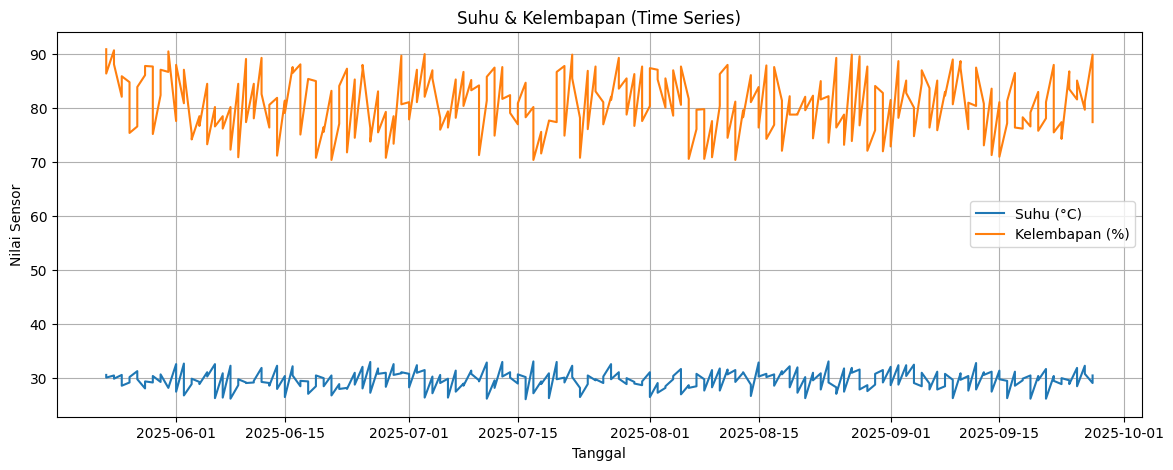

In [ ]:
# ===== Cell 4: Time Series Suhu & Kelembapan =====
# Plot eksplorasi awal untuk melihat pola perubahan suhu dan kelembapan terhadap waktu

plt.figure(figsize=(14,5))

# Plot suhu
plt.plot(pd.to_datetime(df['Tanggal']), df[temp_col], label='Suhu (°C)')

# Plot kelembapan
plt.plot(pd.to_datetime(df['Tanggal']), df[hum_col], label='Kelembapan (%)')

plt.title('Suhu & Kelembapan (Time Series)')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Sensor')
plt.legend()
plt.grid(True)
plt.show()


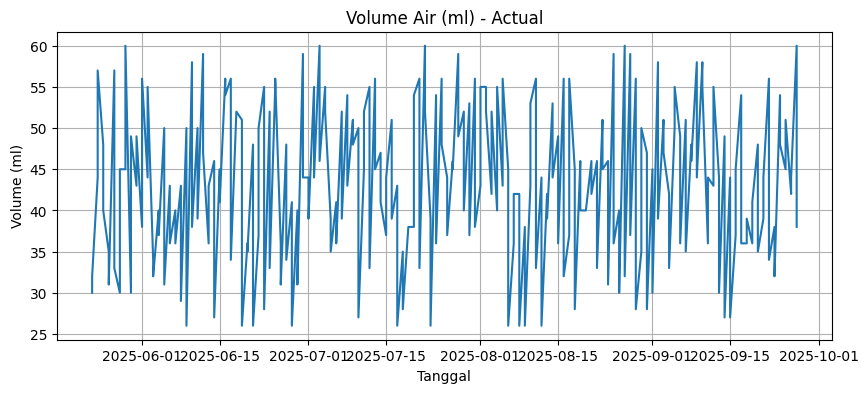

In [ ]:
# ===== Cell 5: Time Series Volume Air (Actual) =====
# Plot untuk melihat perubahan volume air hasil kondensasi terhadap waktu

plt.figure(figsize=(10,4))

# Plot volume air aktual
plt.plot(pd.to_datetime(df['Tanggal']), df[target_col], color='tab:blue')

plt.title('Volume Air (ml) - Actual')
plt.xlabel('Tanggal')
plt.ylabel('Volume (ml)')
plt.grid(True)
plt.show()


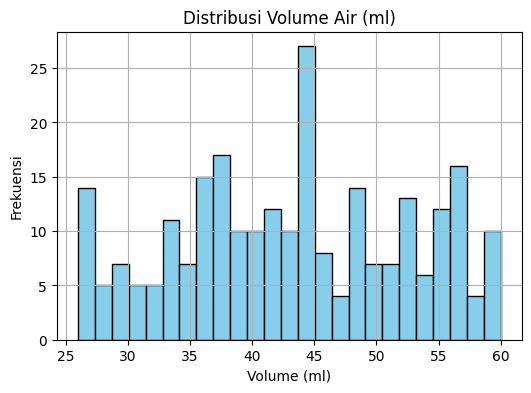

In [ ]:
# ===== Cell 6: Histogram Distribusi Volume Air =====
# Untuk melihat penyebaran dan distribusi nilai volume air

plt.figure(figsize=(6,4))

# Histogram volume
plt.hist(df[target_col].values, bins=25, color='skyblue', edgecolor='black')

plt.title('Distribusi Volume Air (ml)')
plt.xlabel('Volume (ml)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()


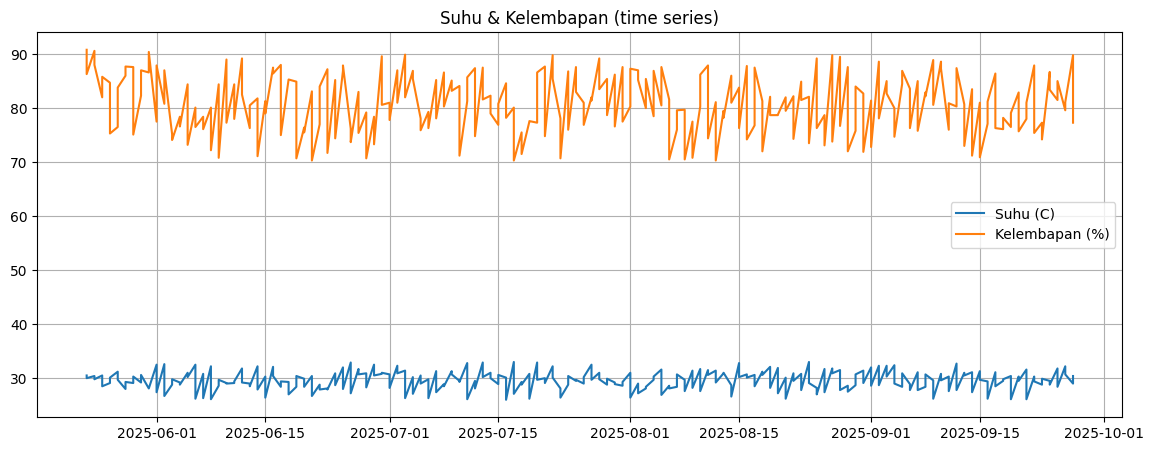

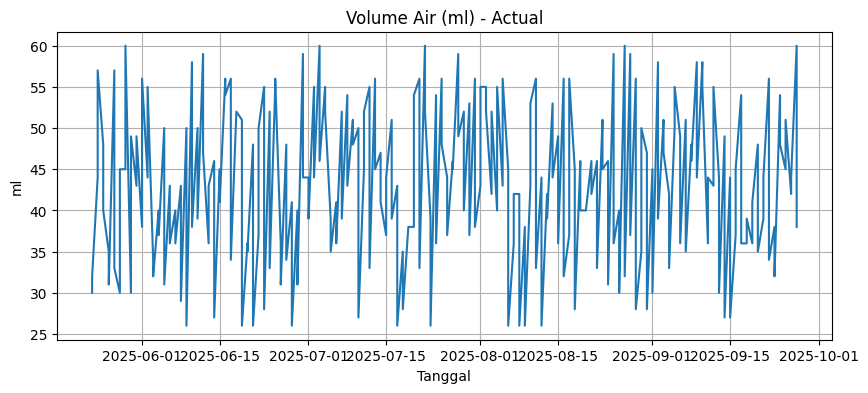

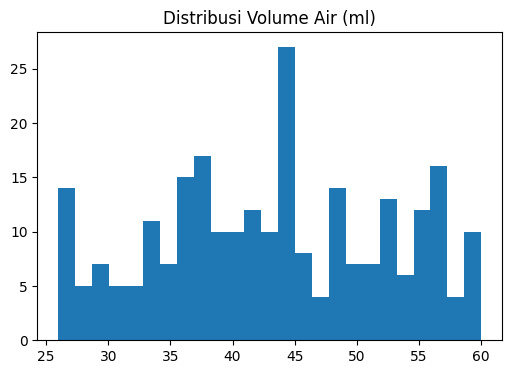

In [ ]:
# ===== Cell 7: Plot eksplorasi data =====

# Membuat plot time series suhu dan kelembapan
plt.figure(figsize=(14,5))
# Plot data suhu terhadap waktu
plt.plot(pd.to_datetime(df['Tanggal']), df[temp_col], label='Suhu (C)')
# Plot data kelembapan terhadap waktu
plt.plot(pd.to_datetime(df['Tanggal']), df[hum_col], label='Kelembapan (%)')
# Menambahkan judul plot
plt.title('Suhu & Kelembapan (time series)')
# Menampilkan legenda dan grid
plt.legend(); plt.grid(True)
# Menampilkan plot
plt.show()

# Membuat plot time series volume air
plt.figure(figsize=(10,4))
# Plot data volume air terhadap waktu
plt.plot(pd.to_datetime(df['Tanggal']), df[target_col], color='tab:blue')
# Menambahkan judul plot
plt.title('Volume Air (ml) - Actual')
# Menambahkan label sumbu Y dan X
plt.ylabel('ml'); plt.xlabel('Tanggal')
# Menampilkan grid
plt.grid(True)
# Menampilkan plot
plt.show()

# Membuat histogram distribusi volume air
plt.figure(figsize=(6,4))
# Membuat histogram dari data volume air dengan 25 bins
plt.hist(df[target_col].values, bins=25)
# Menambahkan judul plot
plt.title('Distribusi Volume Air (ml)')
# Menampilkan plot
plt.show()

In [ ]:
# ===== Cell 8: Rekayasa fitur, scaling, dan pembagian data =====

# Mendefinisikan fitur yang akan digunakan (suhu, kelembapan, dan indikator pagi)
features = [temp_col, hum_col, 'Pagi']
# Mengambil nilai fitur dari DataFrame dan mengonversi ke float
X_raw = df[features].astype(float).values
# Mengambil nilai target (volume air) dari DataFrame dan mengonversi ke float
y_raw = df[[target_col]].astype(float).values

# Opsional: menambahkan fitur lag (geser waktu) - hati-hati dengan data leakage
# df['Air_lag1'] = df[target_col].shift(1)
# kemudian buang baris pertama, dll.

# Melakukan scaling fitur dan target ke range [0,1]
scaler_X = MinMaxScaler()  # Membuat scaler untuk fitur
scaler_y = MinMaxScaler()  # Membuat scaler untuk target
# Transformasi fitur dengan scaling (fit dan transform)
X_scaled = scaler_X.fit_transform(X_raw)
# Transformasi target dengan scaling (fit dan transform)
y_scaled = scaler_y.fit_transform(y_raw)

# Pembagian data dengan mempertimbangkan urutan waktu: 20% terakhir sebagai testing
n = len(X_scaled)  # Jumlah total sampel
n_test = int(np.ceil(0.2 * n))  # Hitung 20% untuk testing (dibulatkan ke atas)
n_train = n - n_test  # Sisa untuk training

# Membagi data training (80% pertama)
X_train = X_scaled[:n_train]  # Fitur training
y_train = y_scaled[:n_train]  # Target training
# Membagi data testing (20% terakhir)
X_test  = X_scaled[n_train:]  # Fitur testing
y_test  = y_scaled[n_train:]  # Target testing

# Menampilkan informasi jumlah sampel
print("Jumlah sampel total/training/testing:", n, n_train, n_test)

Jumlah sampel total/training/testing: 256 204 52


In [ ]:
# ===== Cell 9: BPNN class with momentum & adaptive LR =====
class BPNN_Momentum:
    def __init__(self, n_input, n_hidden, n_output=1,
                 lr=0.01, momentum=0.9, decay=1.0, activation='tanh', seed=42):
        # Set random seed untuk reproducibility
        np.random.seed(seed)

        # Inisialisasi arsitektur jaringan
        self.n_input = n_input  # Jumlah neuron input
        self.n_hidden = n_hidden if isinstance(n_hidden, (list,tuple)) else [n_hidden]  # Jumlah neuron hidden layer (bisa multiple layers)
        self.n_output = n_output  # Jumlah neuron output
        self.lr = lr  # Learning rate awal
        self.momentum = momentum  # Faktor momentum
        self.decay = decay  # Faktor decay learning rate
        self.activation = activation  # Fungsi aktivasi

        # Inisialisasi layer (support multiple hidden layers)
        # Buat list ukuran semua layer: input -> hidden -> output
        layer_sizes = [n_input] + self.n_hidden + [n_output]
        self.W = []  # List untuk menyimpan weight matrices
        self.b = []  # List untuk menyimpan bias vectors

        # Inisialisasi weight dan bias untuk setiap layer
        for i in range(len(layer_sizes)-1):
            in_dim = layer_sizes[i]  # Dimensi input layer saat ini
            out_dim = layer_sizes[i+1]  # Dimensi output layer saat ini
            # Xavier/Glorot initialization untuk menghindari vanishing/exploding gradient
            limit = np.sqrt(6/(in_dim + out_dim))
            # Inisialisasi weight dengan distribusi uniform
            self.W.append(np.random.uniform(-limit, limit, (in_dim, out_dim)))
            # Inisialisasi bias dengan nilai nol
            self.b.append(np.zeros((1, out_dim)))

        # Inisialisasi momentum terms (velocity untuk weight dan bias)
        self.vW = [np.zeros_like(Wi) for Wi in self.W]  # Velocity untuk weights
        self.vb = [np.zeros_like(bi) for bi in self.b]  # Velocity untuk biases

        # Variabel untuk menyimpan loss history
        self.loss_history = []

    # Fungsi aktivasi dan turunannya berdasarkan z (pre-activation)
    def _act(self, z, deriv=False, layer_type='hidden'):
        # Output layer menggunakan fungsi linear (tidak ada aktivasi)
        if layer_type == 'output':
            return (np.ones_like(z) if deriv else z)  # Linear output
        # Fungsi aktivasi tanh
        if self.activation == 'tanh':
            return (1 - np.tanh(z)**2) if deriv else np.tanh(z)  # Turunan atau fungsi tanh
        # Fungsi aktivasi sigmoid
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-z))  # Sigmoid function
            return s*(1-s) if deriv else s  # Turunan atau fungsi sigmoid
        # Fungsi aktivasi ReLU
        if self.activation == 'relu':
            return (z>0).astype(float) if deriv else np.maximum(0, z)  # Turunan atau fungsi ReLU
        raise ValueError("Unknown activation")  # Error jika aktivasi tidak dikenali

    # Forward propagation melalui semua layer
    def forward(self, X):
        A = X  # Aktivasi layer input adalah data input itu sendiri
        self.zs = []  # Menyimpan z values (pre-activation) untuk setiap layer
        self.as_ = [A]  # Menyimpan a values (post-activation) untuk setiap layer

        # Loop melalui hidden layers
        for i in range(len(self.W)-1):
            z = A.dot(self.W[i]) + self.b[i]  # Linear transformation: z = W*a + b
            A = self._act(z, deriv=False, layer_type='hidden')  # Apply activation function
            self.zs.append(z)  # Simpan z value
            self.as_.append(A)  # Simpan a value

        # Output layer (linear activation)
        z_out = A.dot(self.W[-1]) + self.b[-1]  # Linear transformation untuk output
        self.zs.append(z_out)  # Simpan z output
        self.as_.append(z_out)  # Simpan a output (linear)
        return z_out  # Return prediksi

    # Backward propagation dengan momentum
    def backward(self, X, y_true, y_pred):
        m = X.shape[0]  # Jumlah samples dalam batch
        gradsW = [None] * len(self.W)  # List untuk gradient weights
        gradsb = [None] * len(self.b)  # List untuk gradient biases

        # Delta di output layer: turunan MSE terhadap z_out = (y_pred - y_true)
        delta = (y_pred - y_true)  # Shape (m, out_dim)
        # Hitung gradient untuk weight dan bias output layer
        gradsW[-1] = (self.as_[-2].T.dot(delta)) / m  # dL/dW = a_prev.T * delta
        gradsb[-1] = np.sum(delta, axis=0, keepdims=True) / m  # dL/db = sum(delta)

        # Backpropagation melalui hidden layers (dari belakang ke depan)
        for l in range(len(self.n_hidden)-1, -1, -1):
            z_l = self.zs[l]  # Pre-activation layer l
            d_activated = self._act(z_l, deriv=True, layer_type='hidden')  # Turunan fungsi aktivasi
            W_next = self.W[l+1]  # Weight layer berikutnya
            # Propagate error backward: delta_l = (delta_{l+1} * W_{l+1}.T) ⊙ f'(z_l)
            delta = (delta.dot(W_next.T)) * d_activated
            # Hitung gradient untuk layer l
            gradsW[l] = (self.as_[l].T.dot(delta)) / m  # dL/dW_l
            gradsb[l] = np.sum(delta, axis=0, keepdims=True) / m  # dL/db_l

        # Update weight dan bias dengan momentum
        for i in range(len(self.W)):
            # Update velocity: v = momentum*v + (1-momentum)*gradient
            self.vW[i] = self.momentum * self.vW[i] + (1 - self.momentum) * gradsW[i]
            self.vb[i] = self.momentum * self.vb[i] + (1 - self.momentum) * gradsb[i]
            # Update parameters: θ = θ - lr * velocity
            self.W[i] -= self.lr * self.vW[i]
            self.b[i] -= self.lr * self.vb[i]

        # Adaptive learning rate decay
        self.lr *= self.decay  # Kurangi learning rate dengan faktor decay

    # Training loop utama - MODIFIED untuk menampilkan progress seperti contoh
    def train(self, X, y, epochs=5000, verbose_every=500, return_history=True):
        history = []  # Menyimpan history loss untuk plotting

        print(f"Starting training for {epochs} epochs...")
        for ep in range(epochs):
            y_pred = self.forward(X)  # Forward pass
            loss = np.mean((y - y_pred)**2)  # Hitung Mean Squared Error
            history.append(loss)  # Simpan loss
            self.loss_history.append(loss)  # Simpan di instance variable

            self.backward(X, y, y_pred)  # Backward pass + update parameters

            # Print progress secara periodik - MODIFIED seperti contoh
            if ep == 0:
                print(f"Epoch {ep}, Loss:{loss}")
            elif (ep % verbose_every) == 0:
                print(f"Epoch {ep}, Loss:{loss}")
            elif ep == epochs - 1:  # Print epoch terakhir
                print(f"Epoch {ep}, Loss:{loss}")

        # Print prediksi setelah training seperti contoh
        print("Predictions after training:")
        final_predictions = self.predict(X)
        for i in range(min(4, len(final_predictions))):
            print(f"  {final_predictions[i]}")

        print("Trained Model")

        return history if return_history else None  # Return history jika diminta

    # Fungsi untuk melakukan prediksi
    def predict(self, X):
        return self.forward(X)  # Lakukan forward pass untuk mendapatkan prediksi

    # Fungsi tambahan untuk mendapatkan loss history
    def get_loss_history(self):
        return self.loss_history

In [ ]:
# ===== Cell 10: Quick hyperparameter scan (short runs) =====
configs = [
    {'hidden':[8,8], 'lr':0.001, 'momentum':0.9, 'decay':1.0, 'act':'tanh'},
    {'hidden':[8],   'lr':0.001, 'momentum':0.9, 'decay':1.0, 'act':'tanh'},
    {'hidden':[16,8],'lr':0.001,'momentum':0.9, 'decay':1.0, 'act':'tanh'},
]
epochs_tune = 2000 # Increased epochs for more robust tuning
tune_results = []

print("=== HYPERPARAMETER TUNING ===")
for i, cfg in enumerate(configs):
    print(f"\n--- Testing config {i+1}: {cfg} ---")
    m = BPNN_Momentum(n_input=X_train.shape[1], n_hidden=cfg['hidden'], n_output=1,
                      lr=cfg['lr'], momentum=cfg['momentum'], decay=cfg['decay'], activation=cfg['act'], seed=1)
    history = m.train(X_train, y_train, epochs=epochs_tune, verbose_every=epochs_tune+1)
    y_tr = m.predict(X_train)
    mse_tr = mean_squared_error(y_train, y_tr)
    tune_results.append({'cfg':cfg, 'mse_tr':mse_tr, 'model':m, 'history':history})
    print(f"-> MSE train (scaled): {mse_tr}")

best = min(tune_results, key=lambda r: r['mse_tr'])
print(f"\n=== BEST CONFIGURATION ===")
print("Best quick config:", best['cfg'], "MSE_tr:", best['mse_tr'])

=== HYPERPARAMETER TUNING ===

--- Testing config 1: {'hidden': [8, 8], 'lr': 0.001, 'momentum': 0.9, 'decay': 1.0, 'act': 'tanh'} ---
Starting training for 2000 epochs...
Epoch 0, Loss:0.984679902814667
Epoch 1999, Loss:0.04541337613546743
Predictions after training:
  [0.60317583]
  [0.67766378]
  [0.60293135]
  [0.71109261]
Trained Model
-> MSE train (scaled): 0.04539891623481862

--- Testing config 2: {'hidden': [8], 'lr': 0.001, 'momentum': 0.9, 'decay': 1.0, 'act': 'tanh'} ---
Starting training for 2000 epochs...
Epoch 0, Loss:0.771948134405611
Epoch 1999, Loss:0.04621318946093487
Predictions after training:
  [0.8405599]
  [0.58808721]
  [0.83145899]
  [0.61235253]
Trained Model
-> MSE train (scaled): 0.04619778449267966

--- Testing config 3: {'hidden': [16, 8], 'lr': 0.001, 'momentum': 0.9, 'decay': 1.0, 'act': 'tanh'} ---
Starting training for 2000 epochs...
Epoch 0, Loss:0.18793534950194254
Epoch 1999, Loss:0.03173384798587793
Predictions after training:
  [0.79841126]
  [0.

In [ ]:
# ===== Cell 11: TimeSeriesSplit Cross Validation for the best quick config =====
best_cfg = best['cfg']
tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []
fold_no = 1
rmse_per_fold = []
for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model_cv = BPNN_Momentum(n_input=X_train.shape[1], n_hidden=best_cfg['hidden'],
                             n_output=1, lr=best_cfg['lr'], momentum=best_cfg['momentum'],
                             decay=best_cfg['decay'], activation=best_cfg['act'], seed=fold_no*7)
    history_cv = model_cv.train(X_tr, y_tr, epochs=3000, verbose_every=3000+1)
    y_val_pred = model_cv.predict(X_val)
    # inverse scale
    y_val_true_real = scaler_y.inverse_transform(y_val)
    y_val_pred_real = scaler_y.inverse_transform(y_val_pred)
    mets = compute_metrics(y_val_true_real, y_val_pred_real, name=f"Fold {fold_no}")
    fold_metrics.append(mets)
    rmse_per_fold.append(mets['RMSE'])
    fold_no += 1

print("Avg RMSE (CV):", np.mean(rmse_per_fold))


Starting training for 3000 epochs...
Epoch 0, Loss:0.2865072732576654
Epoch 2999, Loss:0.07111349466602161
Predictions after training:
  [0.56090332]
  [0.43068726]
  [0.56157144]
  [0.44207344]
Trained Model
--- Metrik Fold 1 ---
MAE  : 7.5536
MSE  : 72.8057
RMSE : 8.5326
R2   : 0.3201
Starting training for 3000 epochs...
Epoch 0, Loss:0.3879524976200468
Epoch 2999, Loss:0.053227557343998456
Predictions after training:
  [0.6525966]
  [0.57878165]
  [0.64959024]
  [0.60135525]
Trained Model
--- Metrik Fold 2 ---
MAE  : 5.0848
MSE  : 36.9894
RMSE : 6.0819
R2   : 0.5419
Starting training for 3000 epochs...
Epoch 0, Loss:0.3822580609988117
Epoch 2999, Loss:0.039091911458718764
Predictions after training:
  [0.76545512]
  [0.67864267]
  [0.75790669]
  [0.71115784]
Trained Model
--- Metrik Fold 3 ---
MAE  : 3.8156
MSE  : 20.0053
RMSE : 4.4727
R2   : 0.7569
Starting training for 3000 epochs...
Epoch 0, Loss:0.8435127544257902
Epoch 2999, Loss:0.029220725284616732
Predictions after training:

In [ ]:
# ===== Cell 12: Retrain final model on full training set =====
final_cfg = best_cfg
final_epochs = 2000
final_model = BPNN_Momentum(n_input=X_train.shape[1], n_hidden=final_cfg['hidden'],
                            n_output=1, lr=final_cfg['lr'], momentum=final_cfg['momentum'],
                            decay=final_cfg['decay'], activation=final_cfg['act'], seed=999)

print("=== FINAL MODEL TRAINING ===")
history_final = final_model.train(X_train, y_train, epochs=final_epochs, verbose_every=4000)

# Save weights
np.savez('final_bpnn_weights.npz', *final_model.W, *final_model.b)
print("Final model trained and weights saved to 'final_bpnn_weights.npz'")

# Tampilkan beberapa prediksi contoh
print("\n=== SAMPLE PREDICTIONS ===")
sample_predictions = final_model.predict(X_test[:4])
print("Sample test predictions:")
for i, pred in enumerate(sample_predictions):
    print(f"  Sample {i+1}: {pred[0]:.6f}")

=== FINAL MODEL TRAINING ===
Starting training for 2000 epochs...
Epoch 0, Loss:0.3375141020729733
Epoch 1999, Loss:0.025612705444159473
Predictions after training:
  [0.80605695]
  [0.63726777]
  [0.79920316]
  [0.67625188]
Trained Model
Final model trained and weights saved to 'final_bpnn_weights.npz'

=== SAMPLE PREDICTIONS ===
Sample test predictions:
  Sample 1: 0.779003
  Sample 2: 0.417349
  Sample 3: 0.687557
  Sample 4: 0.550275


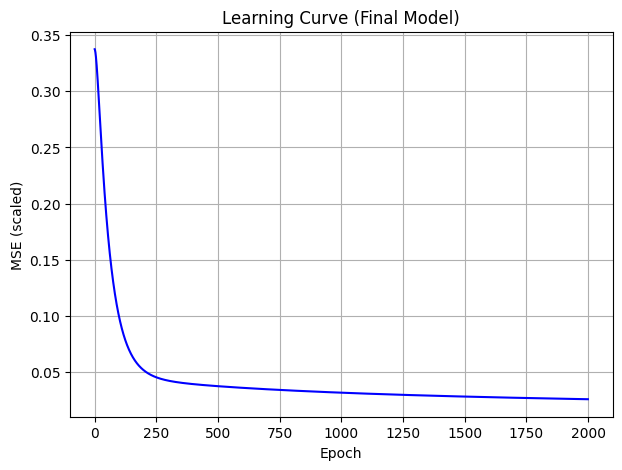

In [ ]:
# ===== Cell 13: Generate Predictions =====

# Generate predictions for training and testing data
y_train_pred_scaled = final_model.predict(X_train)
y_test_pred_scaled = final_model.predict(X_test)

# Inverse transform predictions to original scale
y_train_pred_real = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred_real = scaler_y.inverse_transform(y_test_pred_scaled)

# Inverse transform actual values
y_train_real = scaler_y.inverse_transform(y_train)
y_test_real = scaler_y.inverse_transform(y_test)

# ===== Cell: Plot Learning Curve (Final Model) =====

plt.figure(figsize=(7,5))
plt.plot(history_final, color='blue')
plt.title('Learning Curve (Final Model)')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.grid(True)
plt.show()



In [ ]:
# ===== Cell: Performance Metrics Table =====

# NOTE: Re-generating predictions and inverse transforming here to ensure variables are defined.
# This is done to make this cell self-contained for metric calculation.
# Generate predictions for training and testing data
y_train_pred_scaled = final_model.predict(X_train)
y_test_pred_scaled = final_model.predict(X_test)

# Inverse transform predictions to original scale
y_train_pred_real = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred_real = scaler_y.inverse_transform(y_test_pred_scaled)

# Inverse transform actual values
y_train_real = scaler_y.inverse_transform(y_train)
y_test_real = scaler_y.inverse_transform(y_test)

# Fungsi utilitas untuk menghitung metrik dan menampilkan dengan rapi
def compute_metrics(y_true, y_pred, name=""):
    # Menghitung Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    # Menghitung Root Mean Squared Error
    rmse = np.sqrt(mse)
    # Menghitung Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    # Menghitung R-squared Score
    r2 = r2_score(y_true, y_pred)

    # Menampilkan hasil metrik
    print(f"--- Metrik {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    # Mengembalikan hasil metrik dalam bentuk dictionary
    return {'MAE':mae, 'MSE':mse, 'RMSE':rmse, 'R2':r2}

print("\n--- Evaluating Final Model Performance ---")

# Calculate metrics for the training set
train_metrics = compute_metrics(y_train_real, y_train_pred_real, name="Training")

# Calculate metrics for the testing set
test_metrics = compute_metrics(y_test_real, y_test_pred_real, name="Testing")

# Create a DataFrame for a neat table display
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Testing'],
    'MAE': [train_metrics['MAE'], test_metrics['MAE']],
    'MSE': [train_metrics['MSE'], test_metrics['MSE']],
    'RMSE': [train_metrics['RMSE'], test_metrics['RMSE']],
    'R²': [train_metrics['R2'], test_metrics['R2']]
})

print("\n--- Performance Metrics Table ---")
display(metrics_df)



--- Evaluating Final Model Performance ---
--- Metrik Training ---
MAE  : 4.1860
MSE  : 29.6037
RMSE : 5.4409
R2   : 0.6681
--- Metrik Testing ---
MAE  : 3.4639
MSE  : 15.6220
RMSE : 3.9525
R2   : 0.7794

--- Performance Metrics Table ---


,Dataset,MAE,MSE,RMSE,R²
0,Train,4.185961,29.603671,5.440926,0.668056
1,Testing,3.463856,15.621968,3.952464,0.779370


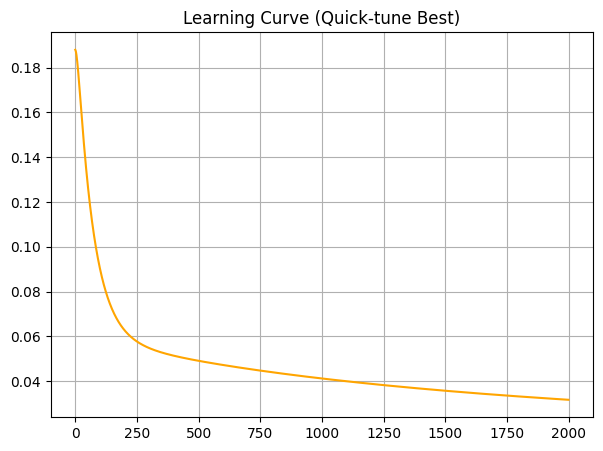

In [ ]:
# ===== Cell 14: Plot Quick-tune Best Learning Curve =====

plt.figure(figsize=(7,5))
if 'history' in best and best['history'] is not None:
    plt.plot(best['history'], color='orange')
    plt.title('Learning Curve (Quick-tune Best)')
else:
    plt.text(0.1, 0.5, 'No quick-tune history', fontsize=12)

plt.grid(True)
plt.show()


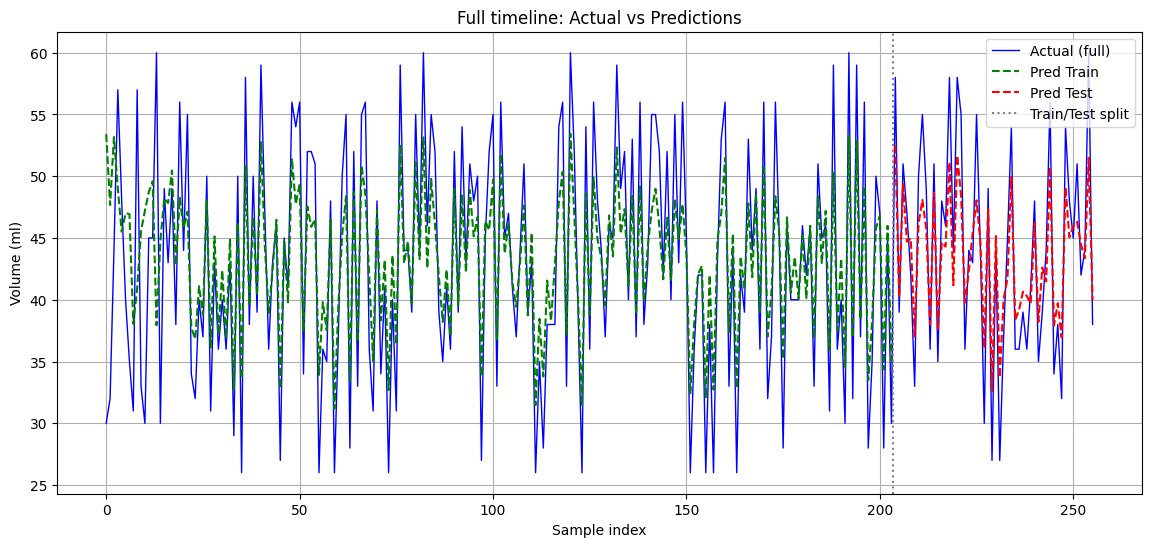

In [ ]:
# ===== Cell 15: Full Timeline Plot =====

y_real_full = np.concatenate([y_train_real, y_test_real])
y_pred_full = np.concatenate([y_train_pred_real, y_test_pred_real])

plt.figure(figsize=(14,6))
plt.plot(range(len(y_real_full)), y_real_full.flatten(), label='Actual (full)', color='blue', linewidth=1)
plt.plot(range(len(y_train_pred_real)), y_train_pred_real.flatten(), label='Pred Train', color='green', linestyle='--')
plt.plot(range(len(y_train_pred_real), len(y_train_pred_real)+len(y_test_pred_real)), y_test_pred_real.flatten(), label='Pred Test', color='red', linestyle='--')

plt.axvline(len(y_train_real)-0.5, color='gray', linestyle=':', label='Train/Test split')
plt.title('Full timeline: Actual vs Predictions')
plt.xlabel('Sample index')
plt.ylabel('Volume (ml)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Pastikan y_test_real dan y_test_pred_real sudah dalam bentuk 1D (flatten)
actual_values = y_test_real.flatten()
predicted_values = y_test_pred_real.flatten()

# Hitung error
errors_individual = actual_values - predicted_values

# Buat DataFrame untuk menampilkan hasilnya
results_df = pd.DataFrame({
    'Data Aktual': actual_values,
    'Data Prediksi': predicted_values,
    'Error': errors_individual
})

# Tampilkan beberapa baris pertama dari DataFrame
print("Tabel Data Aktual, Prediksi, dan Error (Data Uji):")
display(results_df.head())

# Tampilkan juga statistik deskriptif untuk error
print("\nStatistik Deskriptif Error:")
display(results_df['Error'].describe())

Tabel Data Aktual, Prediksi, dan Error (Data Uji):


,Data Aktual,Data Prediksi,Error
0,58.0,52.486098,5.513902
1,39.0,40.189877,-1.189877
2,51.0,49.376923,1.623077
3,47.0,44.709358,2.290642
4,42.0,44.975145,-2.975145



Statistik Deskriptif Error:


,Error
count,52.000000
mean,0.519784
std,3.956363
min,-6.722629
25%,-2.631846
50%,0.977622
75%,3.281439
max,8.516364


In [ ]:
import pandas as pd
import numpy as np

# Gabungkan data aktual dari training dan testing
y_full_actual = np.concatenate([y_train_real, y_test_real]).flatten()

# Gabungkan data prediksi dari training dan testing
y_full_predicted = np.concatenate([y_train_pred_real, y_test_pred_real]).flatten()

# Hitung error untuk seluruh dataset
errors_full = y_full_actual - y_full_predicted

# Buat DataFrame untuk menampilkan hasilnya dengan nama kolom yang diminta
full_results_df = pd.DataFrame({
    'Data Aktual(ml)': y_full_actual,
    'Data Prediksi': y_full_predicted,
    'Error': errors_full
})

# Tampilkan seluruh DataFrame
display(full_results_df)

print("\nStatistik Deskriptif Error (Seluruh Data):")
display(full_results_df['Error'].describe())

,Data Aktual(ml),Data Prediksi,Error
0,30.0,53.405936,-23.405936
1,32.0,47.667104,-15.667104
2,44.0,53.172907,-9.172907
3,57.0,48.992564,8.007436
4,48.0,45.515999,2.484001
...,...,...,...
251,51.0,46.306714,4.693286
252,42.0,44.486446,-2.486446
253,44.0,43.364226,0.635774
254,60.0,51.483636,8.516364



Statistik Deskriptif Error (Seluruh Data):


,Error
count,256.000000
mean,-0.055008
std,5.183199
min,-23.405936
25%,-3.478106
50%,-0.682651
75%,3.782623
max,22.060958


In [ ]:
import sys
!pip install openpyxl --quiet

In [ ]:
from google.colab import files

# Define the Excel file path
excel_file_path = 'prediksi_air_aktual_prediksi_error.xlsx'

# Save the DataFrame to an Excel file
full_results_df.to_excel(excel_file_path, index=False)

# Provide a link to download the file
files.download(excel_file_path)

print(f"Tabel data aktual, prediksi, dan error telah berhasil disimpan ke file Excel dengan nama {excel_file_path}.")
print("Anda sekarang dapat mengunduh file ini dari panel file di sebelah kiri Colab.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabel data aktual, prediksi, dan error telah berhasil disimpan ke file Excel dengan nama prediksi_air_aktual_prediksi_error.xlsx.
Anda sekarang dapat mengunduh file ini dari panel file di sebelah kiri Colab.


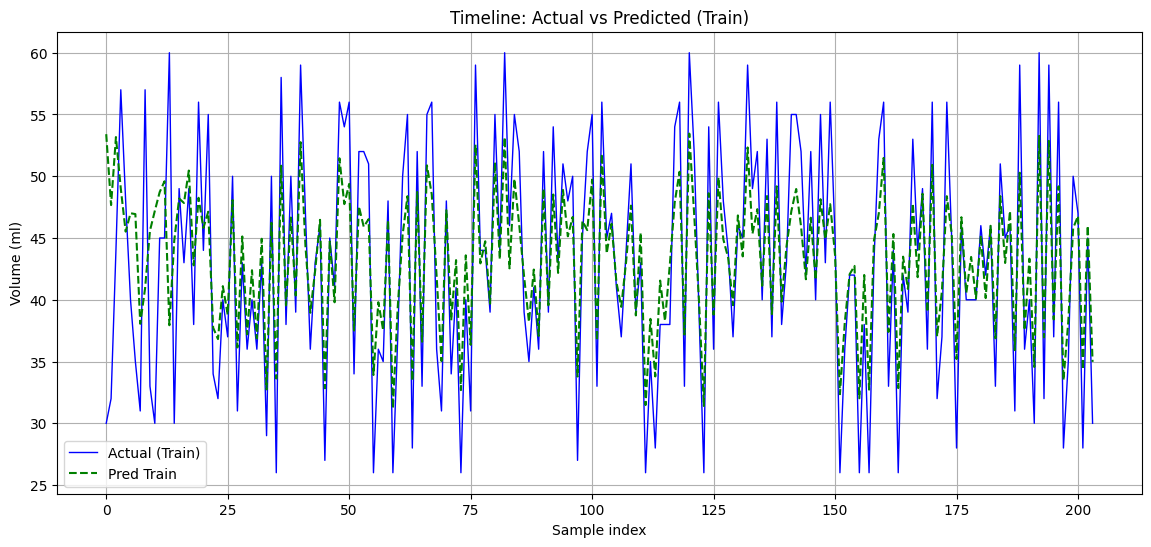

In [ ]:
# ===== Cell 16: Timeline - Actual vs Pred Train =====

plt.figure(figsize=(14,6))

# Actual (train only)
plt.plot(range(len(y_train_real)),
         y_train_real.flatten(),
         label='Actual (Train)',
         color='blue',
         linewidth=1)

# Prediksi (train only)
plt.plot(range(len(y_train_pred_real)),
         y_train_pred_real.flatten(),
         label='Pred Train',
         color='green',
         linestyle='--')

plt.title('Timeline: Actual vs Predicted (Train)')
plt.xlabel('Sample index')
plt.ylabel('Volume (ml)')
plt.legend()
plt.grid(True)
plt.show()


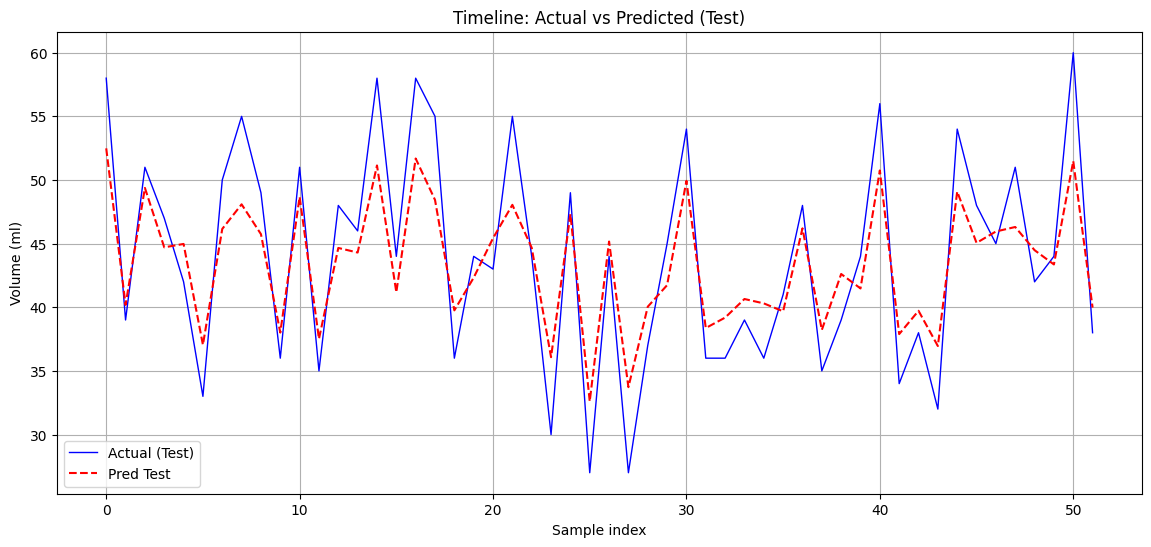

In [ ]:
# ===== Cell 17: Timeline - Actual vs Pred Test =====

plt.figure(figsize=(14,6))

# Actual (test only)
plt.plot(range(len(y_test_real)),
         y_test_real.flatten(),
         label='Actual (Test)',
         color='blue',
         linewidth=1)

# Prediksi (test only)
plt.plot(range(len(y_test_pred_real)),
         y_test_pred_real.flatten(),
         label='Pred Test',
         color='red',
         linestyle='--')

plt.title('Timeline: Actual vs Predicted (Test)')
plt.xlabel('Sample index')
plt.ylabel('Volume (ml)')
plt.legend()
plt.grid(True)
plt.show()


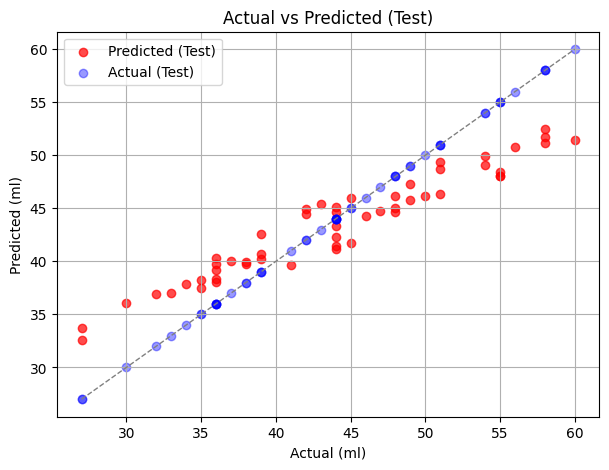

In [ ]:
# ===== Cell 18: Scatter Plot (Actual vs Predicted Test) with Different Colors =====

plt.figure(figsize=(7,5))

# Plot actual values (di sumbu X)
plt.scatter(y_test_real, y_test_pred_real,
            alpha=0.7,
            label='Predicted (Test)',
            color='red')

# Plot titik actual (di garis y=x sebagai referensi)
plt.scatter(y_test_real, y_test_real,
            alpha=0.4,
            label='Actual (Test)',
            color='blue')

# Perfect fit line
mn = min(y_test_real.min(), y_test_pred_real.min())
mx = max(y_test_real.max(), y_test_pred_real.max())
plt.plot([mn, mx], [mn, mx], 'gray', linestyle='--', linewidth=1)

plt.title('Actual vs Predicted (Test)')
plt.xlabel('Actual (ml)')
plt.ylabel('Predicted (ml)')
plt.legend()
plt.grid(True)
plt.show()


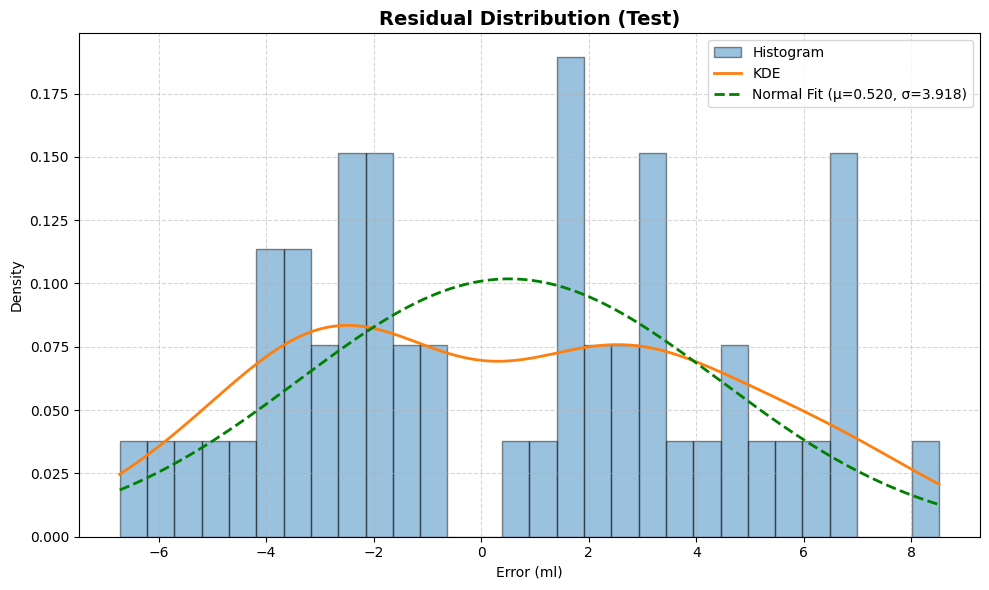

In [ ]:
# ===== Cell: Residual Distribution (Besar & Jelas) =====
from scipy.stats import norm # Added import for norm

plt.figure(figsize=(10,6))   # <<< bikin besar

errors = (y_test_real - y_test_pred_real).flatten()

# Fit distribusi normal
mu, sigma = norm.fit(errors)

x = np.linspace(errors.min(), errors.max(), 200)
pdf = norm.pdf(x, mu, sigma)

# Histogram
plt.hist(errors, bins=30, density=True, alpha=0.45,
         label='Histogram', color='#1f77b4', edgecolor='black')

# KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(errors)
plt.plot(x, kde(x), linewidth=2, color='#ff7f0e', label='KDE')

# Normal curve
plt.plot(x, pdf, linestyle='--', linewidth=2,
         color='green', label=f'Normal Fit (μ={mu:.3f}, σ={sigma:.3f})')

plt.title('Residual Distribution (Test)', fontsize=14, fontweight='bold')
plt.xlabel('Error (ml)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

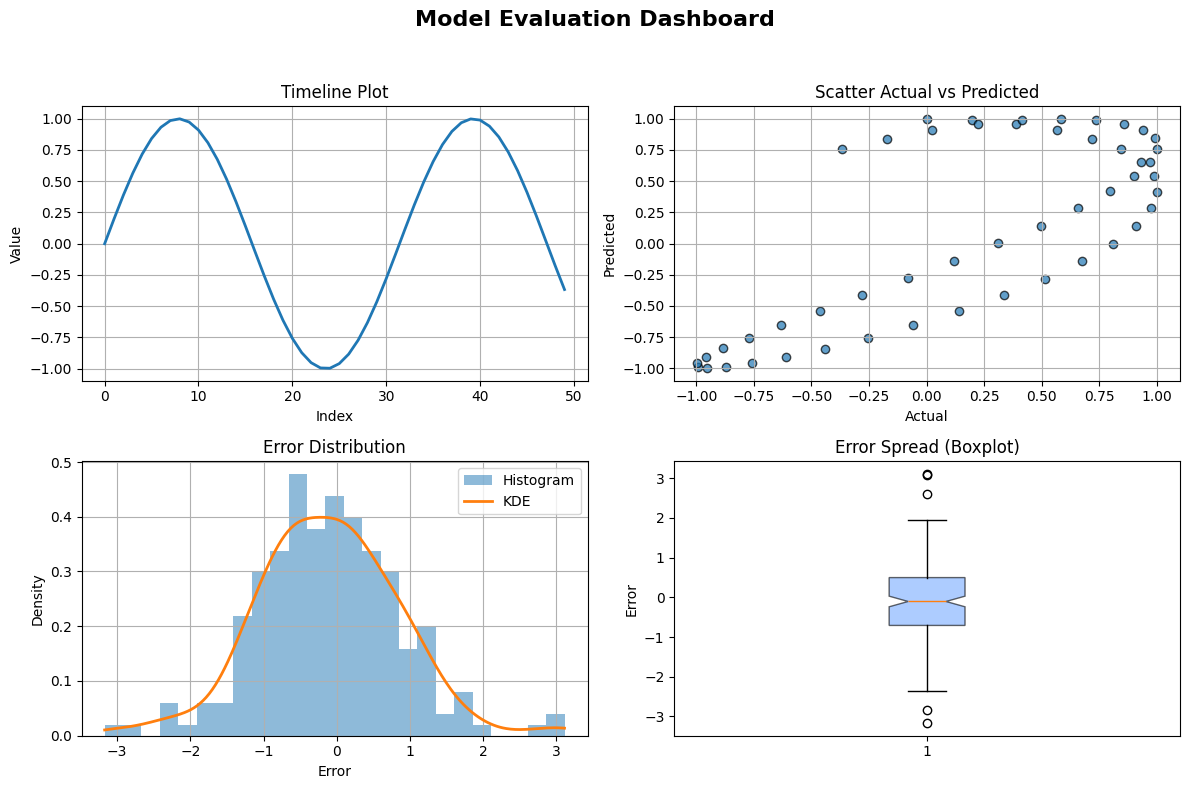

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (silakan ganti)
x = np.arange(0, 50)
y1 = np.sin(x/5)
y2 = np.cos(x/7)
errors = np.random.normal(0, 1, 200)

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Model Evaluation Dashboard", fontsize=16, fontweight='bold')

# -------------------------------
# Panel 1 — Line Plot (Example)
# -------------------------------
ax = axes[0, 0]
ax.plot(x, y1, linewidth=2)
ax.set_title("Timeline Plot")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.grid(True)

# -------------------------------
# Panel 2 — Scatter Plot (Example)
# -------------------------------
ax = axes[0, 1]
ax.scatter(y1, y2, alpha=0.7, edgecolor='k')
ax.set_title("Scatter Actual vs Predicted")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.grid(True)

# -------------------------------
# Panel 3 — Histogram + KDE (Error Distribution)
# -------------------------------
from scipy.stats import gaussian_kde
kde = gaussian_kde(errors)
x_kde = np.linspace(errors.min(), errors.max(), 300)

ax = axes[1, 0]
ax.hist(errors, bins=25, density=True, alpha=0.5, label="Histogram")
ax.plot(x_kde, kde(x_kde), linewidth=2, label="KDE")
ax.set_title("Error Distribution")
ax.set_xlabel("Error")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)

# -------------------------------
# Panel 4 — Boxplot (Example)
# -------------------------------
ax = axes[1, 1]
ax.boxplot(errors, notch=True, patch_artist=True,
           boxprops=dict(facecolor='#77aaff', alpha=0.6))
ax.set_title("Error Spread (Boxplot)")
ax.set_ylabel("Error")

# -------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


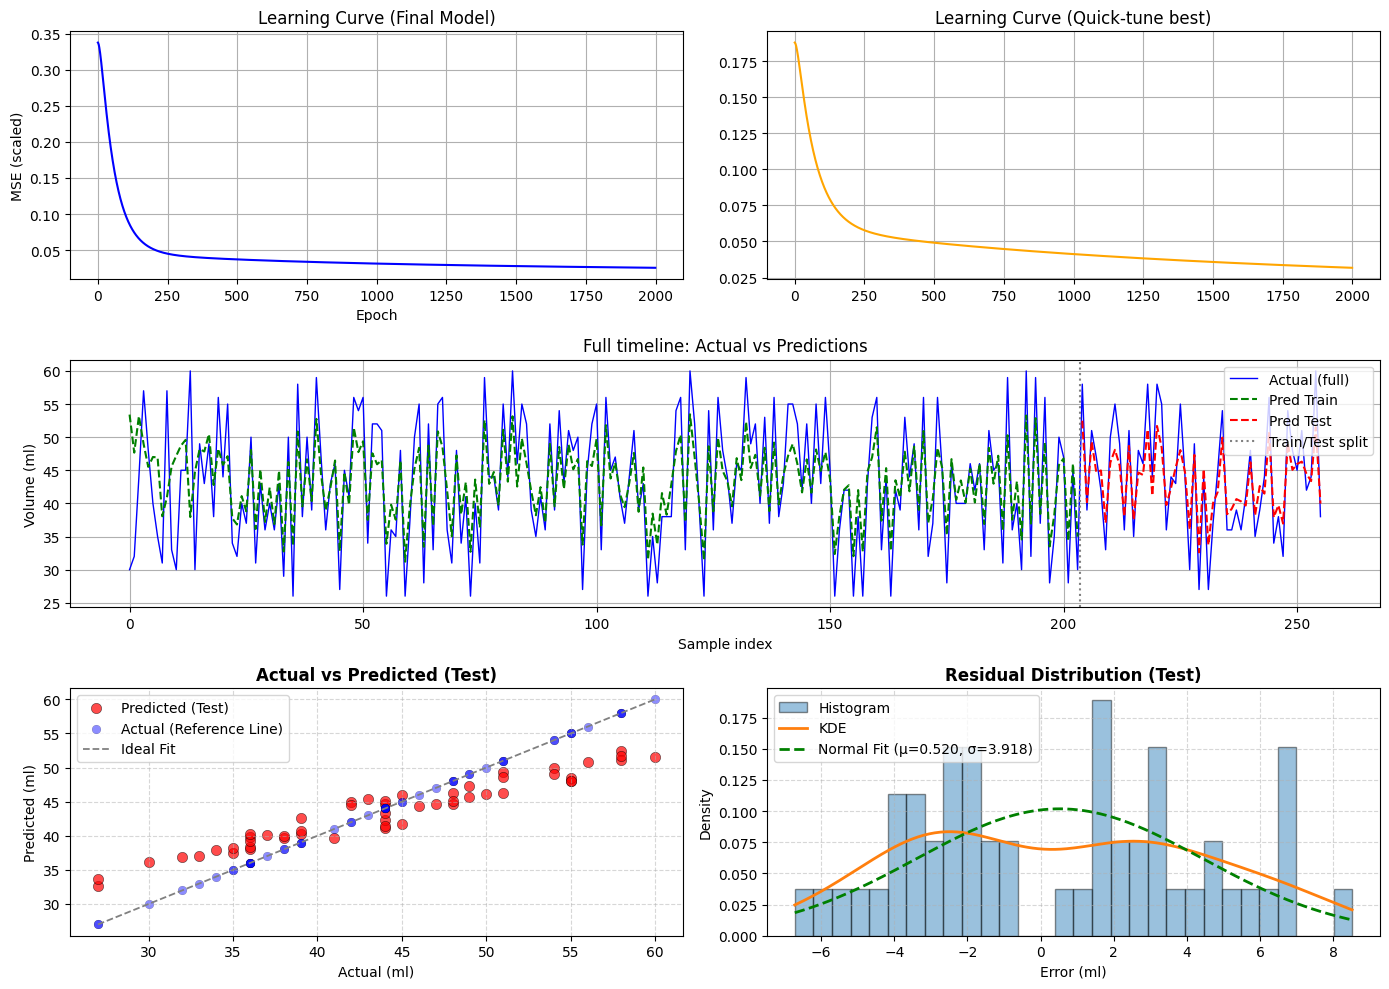

In [ ]:
# ===== Cell 20: Detailed Plots for Reviewer =====
import matplotlib.gridspec as gridspec

# Generate predictions for training and testing data
y_train_pred_scaled = final_model.predict(X_train)
y_test_pred_scaled = final_model.predict(X_test)

# Inverse transform predictions to original scale
y_train_pred_real = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred_real = scaler_y.inverse_transform(y_test_pred_scaled)

# Inverse transform actual values to original scale for comparison
y_train_real = scaler_y.inverse_transform(y_train)
y_test_real = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(14,10))
gs = gridspec.GridSpec(3,2, height_ratios=[1,1,1])

# 1) Learning curve (final)
ax0 = plt.subplot(gs[0,0])
ax0.plot(history_final, color='blue')
ax0.set_title('Learning Curve (Final Model)')
ax0.set_xlabel('Epoch'); ax0.set_ylabel('MSE (scaled)')
ax0.grid(True)

# 2) Learning curve (quick-tune best) for comparison (if exists)
ax1 = plt.subplot(gs[0,1])
if 'history' in best and best['history'] is not None:
    ax1.plot(best['history'], color='orange')
    ax1.set_title('Learning Curve (Quick-tune best)')
else:
    ax1.text(0.1,0.5,'No quick-tune history', fontsize=12)
ax1.grid(True)

# 3) Full timeline: actual vs train & test predictions
ax2 = plt.subplot(gs[1,:])
y_real_full = np.concatenate([y_train_real, y_test_real])
y_pred_full = np.concatenate([y_train_pred_real, y_test_pred_real])
ax2.plot(range(len(y_real_full)), y_real_full.flatten(), label='Actual (full)', color='blue', linewidth=1)
ax2.plot(range(len(y_train_pred_real)), y_train_pred_real.flatten(), label='Pred Train', color='green', linestyle='--')
ax2.plot(range(len(y_train_pred_real), len(y_train_pred_real)+len(y_test_pred_real)), y_test_pred_real.flatten(), label='Pred Test', color='red', linestyle='--')
ax2.axvline(len(y_train_real)-0.5, color='gray', linestyle=':', label='Train/Test split')
ax2.set_title('Full timeline: Actual vs Predictions')
ax2.set_xlabel('Sample index'); ax2.set_ylabel('Volume (ml)')
ax2.legend(); ax2.grid(True)

# 4) Scatter Actual vs Predicted (Test)
# 4) Scatter Actual vs Predicted (Test) – NEW VERSION
ax3 = plt.subplot(gs[2, 0])

# Titik Prediksi
ax3.scatter(
    y_test_real,
    y_test_pred_real,
    alpha=0.7,
    label='Predicted (Test)',
    color='red',
    edgecolor='black',
    linewidth=0.4,
    s=55
)

# Titik Actual (garis referensi diagonal)
ax3.scatter(
    y_test_real,
    y_test_real,
    alpha=0.45,
    label='Actual (Reference Line)',
    color='blue',
    edgecolor='black',
    linewidth=0.2,
    s=40
)

# Perfect Fit Line (y = x)
mn = min(y_test_real.min(), y_test_pred_real.min())
mx = max(y_test_real.max(), y_test_pred_real.max())
ax3.plot([mn, mx], [mn, mx],
         linestyle='--',
         color='gray',
         linewidth=1.3,
         label='Ideal Fit')

# Title & Label
ax3.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Actual (ml)')
ax3.set_ylabel('Predicted (ml)')

# Grid & Legend
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend()


# 5) Residual Distribution (Histogram + KDE + Normal Curve) – NEW VERSION
ax4 = plt.subplot(gs[2, 1])

# Residuals
errors = (y_test_real - y_test_pred_real).flatten()

# Fit distribusi normal
mu, sigma = norm.fit(errors)

# Range kurva
x = np.linspace(errors.min(), errors.max(), 200)
pdf = norm.pdf(x, mu, sigma)

# Histogram residual
ax4.hist(errors, bins=30, density=True, alpha=0.45,
         label='Histogram', color='#1f77b4', edgecolor='black')

# KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(errors)
ax4.plot(x, kde(x), linewidth=2, color='#ff7f0e', label='KDE')

# Normal curve
ax4.plot(x, pdf, linestyle='--', linewidth=2,
         color='green', label=f'Normal Fit (μ={mu:.3f}, σ={sigma:.3f})')

# Title & axis labels
ax4.set_title('Residual Distribution (Test)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Error (ml)')
ax4.set_ylabel('Density')

# Grid + Legend
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend()


plt.tight_layout()
plt.show()

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# =========================
# MEMBANGUN MODEL BPNN
# =========================
model = Sequential()

# Input Layer + Hidden Layer
model.add(Dense(
    units=16,
    activation='relu',
    input_dim=3
))

# Hidden Layer Kedua
model.add(Dense(
    units=8,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='linear'
))

# =========================
# COMPILE MODEL
# =========================
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

# =========================
# MENAMPILKAN SUMMARY MODEL
# =========================
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import os # Import os module to check file existence
import zipfile # Import zipfile to catch BadZipFile exception explicitly

file_name = 'final_bpnn_weights.npz'

# 1. Memuat file .npz
# First, check if the file exists.
if not os.path.exists(file_name):
    print(f"Error: File '{file_name}' not found.")
    print("Please ensure Cell 12 (final model training) has been run successfully to create this file.")
else:
    try:
        data = np.load(file_name)

        # 2. Melihat daftar nama array (keys) yang tersimpan di dalamnya
        print("Isi file:", data.files)
        # Contoh output: ['arr_0', 'arr_1'] atau ['features', 'labels']

        # 3. Mengambil array tertentu berdasarkan nama key-nya
        # Assuming the weights and biases are saved as 'arr_0', 'arr_1', etc.
        # It's good practice to ensure these keys exist.
        if 'arr_0' in data.files and 'arr_1' in data.files:
            X = data['arr_0']
            y = data['arr_1']

            print("Bentuk data X:", X.shape)
            print("Bentuk data y:", y.shape) # Added print for y.shape for completeness
        else:
            print(f"Error: Expected keys 'arr_0' and 'arr_1' not found in '{file_name}'.")
            print("The file contains: {data.files}. Please check how the model weights were saved in Cell 12.")

    except zipfile.BadZipFile as e: # Catch zipfile.BadZipFile directly
        print(f"Error loading '{file_name}': {e}")
        print("This error means the .npz file is corrupted or was not saved correctly.")
        print("Please try re-running Cell 12 to regenerate 'final_bpnn_weights.npz' and then run this cell again.")
    except Exception as e:
        print(f"An unexpected error occurred while loading '{file_name}': {e}")

Isi file: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5']
Bentuk data X: (3, 16)
Bentuk data y: (16, 8)
